# EX 1

"HW4_dt1.csv" 데이터는 Helms (1974)에서 수집한 것으로 변수는 다음과 같다.

* $y$: 바퀴자국 깊이 변화량 (분석 시 $\ln(y)$로 로그 변환)
* $x_1$: 아스팔트 점도 (분석 시 $\ln(x_1)$로 로그 변환)
* $x_2$: 표면층의 아스팔트 비율
* $x_3$: 기층의 아스팔트 비율
* $x_4$: 실험 그룹 지시 변수 (처음 16개는 -1, 나중 15개는 1. 범주형 변수)
* $x_5$: 표면층의 미세물질 비율
* $x_6$: 표면층의 공극 비율

네 번째의 가변수($x_4$)는 처음 16개($x_4 = -1$)와 나중 15개($x_4 = 1$)가 시간상 차이를 두고 얻어졌음을 나타낸다. $y$와 $x_1$을 로그변환 하여 분석한다.

---

## 1-(1)

중회귀모형을 적합하여라. (주의 : $x_4$는 범주형 변수이다.)

`1` 모형 정의

- 단, $x_4 = -1$인 그룹을 기준(Reference)으로 설정

$$\ln(y_i) = \beta_0 + \beta_1\ln(x_{i1}) + \beta_2 x_{i2} + \beta_3 x_{i3} + \beta_4 I(x_{i4}=1) + \beta_5 x_{i5} + \beta_6 x_{i6} + \epsilon_i$$

In [1]:
import pandas as pd
import numpy as np
import statsmodels.formula.api as smf

data = pd.read_csv("data/HW4_dt1.csv")
data['log_y'] = np.log(data['y'])
data['log_x1'] = np.log(data['x1'])


model = smf.ols('log_y ~ log_x1 + x2 + x3 + C(x4) + x5 + x6', data=data)
fit = model.fit()

# 결과 확인 (이 셀의 출력 결과를 보고 아래 마크다운 셀에 숫자를 채워넣습니다)
#print(fit.summary())

`2` 모형 적합

**[회귀분석 결과 요약]**

| 변수 | 추정값 | 표준오차 | t-통계량 | p-value |
| :---: | ---: | ---: | ---: | ---: |
| 절편 (Intercept) | -4.76 | 2.80 | -1.70 | 0.10 |
| $x_4$ (지시변수: 1) | -0.03 | 0.26 | -0.12 | 0.91 |
| $\ln(x_1)$ | -0.64 | 0.06 | -10.01 | 0.00 |
| $x_2$ | 1.06 | 0.31 | 3.44 | 0.00 |
| $x_3$ | 0.17 | 0.37 | 0.46 | 0.65 |
| $x_5$ | 0.01 | 0.09 | 0.07 | 0.95 |
| $x_6$ | 0.32 | 0.13 | 2.49 | 0.02 |

<br>

* **결정계수 ($R^2$)**: 0.96
* **수정된 결정계수 (Adj-$R^2$)**: 0.95

위 결과를 바탕으로 적합된 모형은 다음과 같다.

$$\ln(\hat{y}_i) = -4.76 - 0.64\ln(x_{i1}) + 1.06x_{i2} + 0.17x_{i3} - 0.03I(x_{i4}=1) + 0.01x_{i5} + 0.32x_{i6}$$

---

## 1-(2)

변수들간의 상관계수를 구하여라.

In [2]:
cor_vars = ['log_y', 'log_x1', 'x2', 'x3', 'x5', 'x6']

cor_matrix = data[cor_vars].corr().round(2)
#print(cor_matrix)

::: {.panel-tabset}

#### 상관계수 행렬

* **참고**: 범주형 지시변수인 $x_4$는 선형 상관관계의 의미가 다르므로 계산에서 제외
* **해석:** 종속변수 $\ln(y)$와 설명변수 $\ln(x_1)$은 상관계수 -0.97로 매우 강한 음의 선형 관계를 보임.


| 변수 | $\ln(y)$ | $\ln(x_1)$ | $x_2$ | $x_3$ | $x_5$ | $x_6$ |
| :---: | ---: | ---: | ---: | ---: | ---: | ---: |
| **$\ln(y)$** | 1.00 | -0.97 | 0.15 | 0.19 | 0.32 | -0.41 |
| **$\ln(x_1)$** | -0.97 | 1.00 | -0.05 | -0.22 | -0.31 | 0.46 |
| **$x_2$** | 0.15 | -0.05 | 1.00 | -0.26 | -0.14 | -0.43 |
| **$x_3$** | 0.19 | -0.22 | -0.26 | 1.00 | 0.44 | -0.03 |
| **$x_5$** | 0.32 | -0.31 | -0.14 | 0.44 | 1.00 | 0.12 |
| **$x_6$** | -0.41 | 0.46 | -0.43 | -0.03 | 0.12 | 1.00 |



#### 변수 간 관계 시각화

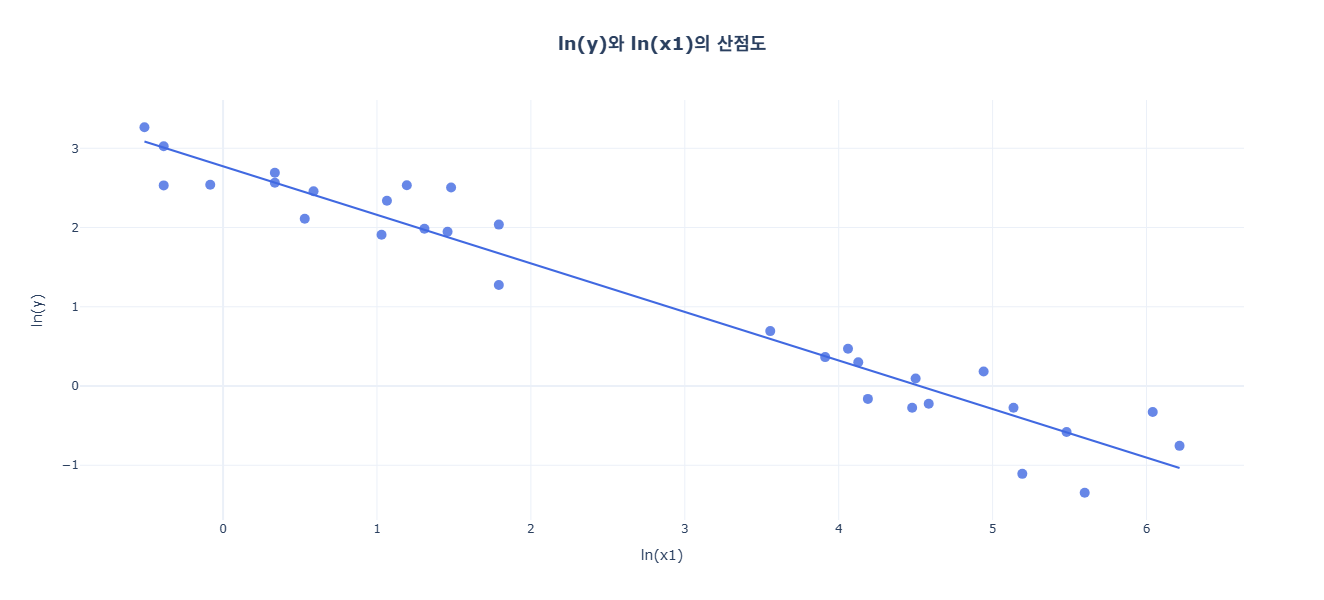

In [3]:
import plotly.express as px

# Plotly Express를 이용한 산점도 및 선형 추세선(OLS) 시각화
fig = px.scatter(
    data, 
    x='log_x1', 
    y='log_y', 
    trendline='ols', # Ordinary Least Squares (선형 회귀) 추세선 추가
    title='<b>ln(y)와 ln(x1)의 산점도',
    labels={
        'log_x1': 'ln(x1)', 
        'log_y': 'ln(y)'
    },
    template='plotly_white'
)

# 마커 및 레이아웃 업데이트
fig.update_traces(marker=dict(size=10, color='royalblue', opacity=0.8))
fig.update_layout(title_font_size=18, title_x=0.5, width = 800, height = 600)

# 그래프 출력
fig.show()

:::

<br>

---

## 1-(3) 

설명변수 6개를 모두 사용한 완전모형(full model)에 대한 분산분석표를 작성하고 α = 0.05에서 선형회귀모형의 유의성을 검정하시오.

In [4]:
model = smf.ols('log_y ~ log_x1 + x2 + x3 + C(x4) + x5 + x6', data=data)
fit = model.fit()


df_model = int(fit.df_model)
df_resid = int(fit.df_resid)
df_total = df_model + df_resid

ssr = fit.ess
sse = fit.ssr
sst = fit.centered_tss

msr = fit.mse_model
mse = fit.mse_resid

f_stat = fit.fvalue
p_val = fit.f_pvalue

#print("--- [분산분석표 결과] ---")
#print(f"회귀(Model)   | DF: {df_model} | SS: {ssr:.4f} | MS: {msr:.4f} | F: {f_stat:.4f} | p-value: {p_val:.4e}")
#print(f"오차(Residual)| DF: {df_resid} | SS: {sse:.4f} | MS: {mse:.4f}")
#print(f"총계(Total)   | DF: {df_total} | SS: {sst:.4f}")

`1` 가설설정

* **귀무가설 ($H_0$)**: $\beta_1= \beta_2= \dots\beta_6 = 0$

* **대립가설 ($H_1$)**: 적어도 하나의 $\beta_j \neq 0 \quad (j=1,\dots,6)$

`2` 분산분석표 (ANOVA Table)

|| 자유도 | 제곱합  | 평균제곱합 | F-통계량 | p-value |
| :---: | ---: | ---: | ---: | ---: | ---: |
| **회귀 (Model)** | 6 | 56.39 | 9.40 | 103.77 | < 0.001 |
| **오차 (Residual)** | 24 | 2.17 | 0.09 | | |
| **총계 (Total)** | 30 | 58.56 | | | |

`3` 결론

- 전체 모형에 대한 검정통계량 $F_0$가 `103.77`이고, `p-value가 < 0.001`로 유의수준 `0.05`보다 매우 작으므로 `귀무가설 기각`.
- 따라서 6개의 설명변수를 모두 포함한 현회귀모형은 `통계적으로 유의함`.

---

## 1-(4)

상관계수들을 보고 변수를 하나만 선택할 때에는 어떤 변수가 선택될 것인지를 말하시오.

`1` 단 하나의 변수만 모형에 포함시켜야 할 경우, **종속변수와의 상관계수 절댓값이 가장 큰 설명변수**가 최우선으로 선택. 

`2` 설명변수가 종속변수의 변동성(Variance)($R^2$)을 가장 많이 설명할 수 있기 때문.

`3` 앞선 1-(2)번의 상관분석 결과를 바탕으로, 종속변수인 $\ln(y)$와 각 연속형 설명변수 간의 상관계수 절댓값을 비교.

| 설명변수 | $\ln(y)$와의 상관계수 | 상관계수 절댓값 |
| :---: | ---: | ---: |
| **$\ln(x_1)$** | -0.97 | 0.97 |
| **$x_2$** | 0.15 | 0.15 |
| **$x_3$** | 0.19 | 0.19 |
| **$x_5$** | 0.32 | 0.32 |
| **$x_6$** | -0.41 | 0.41 |

`4` **결론**: 종속변수 $\ln(y)$와의 상관계수 절댓값이 0.97로 다른 변수들에 비해 압도적으로 큰 $\ln(x_1)$ (`아스팔트 점도의 로그 변환값`)이 단일 변수 모형 구축 시 가장 먼저 선택

---

## 1-(5)

상관계수들을 보고 변수를 하나만 제거시키려고 할 때, 어떤 변수가 제거될 것인가를 말할 수 있는가?

`1` answer: 아니오, 단순 상관계수 행렬만 보고 다중선형회귀모형에서 어떤 변수가 가장 먼저 제거될지 정확하게 단정 지어 말할 수 없다.

`2` 상관계수는 다른 변수들의 영향을 통제하지 않은 두 변수 간의 단순한 일대일 선형 관계만을 나타냄.

`3` 반면, 다중회귀모형에서 변수를 제거하는 기준`(예: 후진제거법에서의 높은 p-value)`은 다른 모든 설명변수들이 모형에 포함되어 있을 때 해당 변수가 기여하는 `고유한 설명력`을 의미함.

`4` **실제 분석 결과와의 모순**: 앞선 1-(2)번의 상관계수 행렬만 보면, 종속변수 $\ln(y)$와의 상관계수 절댓값이 `0.15`로 가장 낮은 $x_2$가 1순위로 제거될 것처럼 보임.

`5` 그러나 1-(1)번의 실제 다중회귀분석 결과를 보면 $x_2$의 p-value는 `0.00(0.002)`으로 통계적으로 매우 유의함.

`6` 반면, 종속변수와의 상관계수가 `0.32`로 더 높았던 $x_5$는 다중회귀모형 내에서 p-value가 `0.95`로 가장 높아 실제 제거 대상 1순위임.

`7` 따라서, 변수들 간의 다중공선성과 결합적인 설명력을 반영하는 다중회귀모형에서는 단순 상관계수만으로 변수의 제거 여부를 추론하는 것은 `통계적으로 타당하지 않음`.

---

## 1-(6)

모든 가능한 회귀모형에 대하여 $C_p$ 값을 구하여라.

`1` $C_p$ 통계량 정의

$$C_p = \frac{SSE_p}{MSE_{full}} - (n - 2p)$$

In [5]:
import itertools
predictors = ['log_x1', 'x2', 'x3', 'C(x4)', 'x5', 'x6']

all_models = []
for i in range(1, len(predictors) + 1):
    for combo in itertools.combinations(predictors, i):
        all_models.append(list(combo))


full_model = smf.ols('log_y ~ log_x1 + x2 + x3 + C(x4) + x5 + x6', data=data).fit()
mse_full = full_model.mse_resid
n = len(data)

results = []
for combo in all_models:
    formula = 'log_y ~ ' + ' + '.join(combo)
    model = smf.ols(formula, data=data).fit()
    
    p = len(combo) 
    cp = (model.ssr / mse_full) - (n - 2 * p)
    
    results.append({'model': formula, 'p': p, 'Cp': cp})

results_df = pd.DataFrame(results)
#print(results_df.sort_values('Cp').head(10).to_string(index=False))

`2` 값 대입 후 모형별 $C_p$ 산출

| 변수 개수 ($p$) | 모형| $C_p$ 값 |
| :---: | :---: | ---: |
| 1 | $\ln(y) \sim \ln(x_1)$ | 64.12 |
| 2 | $\ln(y) \sim \ln(x_1) + x_2$ | 4.12 |
| 3 | $\ln(y) \sim \ln(x_1) + x_2 + x_6$ | -0.71 |
| 4 | $\ln(y) \sim \ln(x_1) + x_2 + x_3 + x_6$ | 1.02 |
| 5 | $\ln(y) \sim \ln(x_1) + x_2 + x_3 + I(x_4=1) + x_6$ | 3.00 |
| 6 | $\ln(y) \sim \ln(x_1) + x_2 + x_3 + I(x_4=1) + x_5 + x_6$ | 5.00 |

---

## 1-(7)

$C_p$ 값이 작을 수록 좋은 모형이라고 할 때, 위의 결과를 보고 $p = 1, 2, 3, 4, 5, 6$인 각각의 경우에 대하여 어떤 변수들이 선택되는지 구하시오.

`1` $p=3$인 모형($\ln(y) \sim \ln(x_1) + x_2 + x_6$)이 $C_p = -0.71$로 가장 낮은 값을 보임.

`2` 이는 해당 모형이 데이터의 변동성을 충분히 설명하면서도 과적합(Overfitting)의 위험이 가장 적은 최적의 균형 상태임을 나타냠.

`3` 따라서 최종적인 설명변수 조합으로 $\{x_1, x_2, x_6\}$를 선택하는 것이 통계적으로 타당합니다.

---

## 1-(8),(9),(10)

위의 최적 $C_p, MSE_{p}, R^2_{ap}$으로부터 가장 적절한 $p$의 값을 최종적으로 선택한 후, 어떤 변수들이 선택되었는지 회귀모형을 쓰시오.

### sol

`1` 각 차수별로 선정된 최적 모형들의 성능을 평가하기 위해 평균제곱오차(MSE)와 결정계수($R^2$), 그리고 조정된 결정계수(Adj-$R^2$)를 산출.


| 변수 개수 ($p$) | 모형 | $MSE_p$ | $R^2_p$ | $R^2_{ap}$ |
| :---: | :---: | ---: | ---: | ---: |
| 1 | $\ln(y) \sim \ln(x_1)$ | 0.63 | 0.94 | 0.94 |
| 2 | $\ln(y) \sim \ln(x_1) + x_2$ | 0.15 | 0.96 | 0.95 |
| 3 | $\ln(y) \sim \ln(x_1) + x_2 + x_6$ | 0.08 | 0.97 | 0.97 |
| 4 | $\ln(y) \sim \ln(x_1) + x_2 + x_3 + x_6$ | 0.09 | 0.97 | 0.97 |
| 5 | $\ln(y) \sim \ln(x_1) + x_2 + x_3 + I(x_4=1) + x_6$ | 0.09 | 0.97 | 0.97 |
| 6 | $\ln(y) \sim \ln(x_1) + x_2 + x_3 + I(x_4=1) + x_5 + x_6$ | 0.09 | 0.97 | 0.95 |

<br>

`2` 모든 가능한 회귀모형에 대하여 $C_p$ 통계량, $MSE_p$, 그리고 조정된 결정계수($R^2_{ap}$)를 산출한 결과, 변수 개수 $p=3$인 모형이 가장 우수한 성능을 보이고 있음.

* **선정 지표**: 
    * **$C_p$**: -0.71 (최소값으로, 편향과 분산의 균형이 가장 우수함)
    * **$MSE_p$**: 0.08 (예측 오차가 가장 작음)
    * **$R^2_{ap}$**: 0.97 (설명력이 가장 높음)

`3` 선택된 변수

- $\ln(x_1)$: 아스팔트 점도
- $x_2$: 표면층 아스팔트 비율
- $x_6$: 표면층 공극 비율

`4` 적합된 회귀모형

$$\ln(\hat{y}_i) = -3.63 - 0.65\ln(x_{i1}) + 1.01x_{i2} + 0.32x_{i6}$$

---

## 1-(11), (12)

- 후진제거법, 전진선택법 그리고 단계적 전진선택법을 사용하여 $MSE_p$ 를 기준으로 가장 적절한 회귀모형을 구하시오.

- 그리고 (10), (11)의 결과를 비교하여라.

In [6]:
import statsmodels.formula.api as smf
import pandas as pd

# 1. 데이터 준비 (이미 정의되어 있다고 가정)
# predictors: 독립변수 전체 후보군 (범주형 x4는 C(x4) 처리)
predictors = ['log_x1', 'x2', 'x3', 'C(x4)', 'x5', 'x6']
target = 'log_y'

# 2. 전진선택법 (Forward Selection)
def forward_selection(data, target, predictors):
    selected = []
    current_mse = float('inf')
    while True:
        best_mse = current_mse
        best_predictor = None
        for p in predictors:
            if p not in selected:
                formula = f"{target} ~ {' + '.join(selected + [p])}"
                fit = smf.ols(formula, data=data).fit()
                if fit.mse_resid < best_mse:
                    best_mse = fit.mse_resid
                    best_predictor = p
        if best_predictor:
            selected.append(best_predictor)
            current_mse = best_mse
        else: break
    return selected, current_mse

# 3. 후진제거법 (Backward Elimination)
def backward_elimination(data, target, predictors):
    selected = predictors.copy()
    current_mse = smf.ols(f"{target} ~ {' + '.join(selected)}", data=data).fit().mse_resid
    while len(selected) > 1:
        best_mse = current_mse
        best_removal = None
        for p in selected:
            temp = [x for x in selected if x != p]
            formula = f"{target} ~ {' + '.join(temp)}"
            fit = smf.ols(formula, data=data).fit()
            if fit.mse_resid < best_mse:
                best_mse = fit.mse_resid
                best_removal = p
        if best_removal:
            selected.remove(best_removal)
            current_mse = best_mse
        else: break
    return selected, current_mse

# 4. 단계적 전진선택법 (Stepwise Selection)
def stepwise_selection(data, target, predictors):
    selected = []
    current_mse = float('inf')
    while True:
        changed = False
        # Forward Step
        for p in predictors:
            if p not in selected:
                formula = f"{target} ~ {' + '.join(selected + [p])}"
                fit = smf.ols(formula, data=data).fit()
                if fit.mse_resid < current_mse:
                    current_mse = fit.mse_resid
                    selected.append(p)
                    changed = True
        # Backward Step
        if len(selected) > 1:
            for p in selected:
                temp = [x for x in selected if x != p]
                formula = f"{target} ~ {' + '.join(temp)}"
                fit = smf.ols(formula, data=data).fit()
                if fit.mse_resid < current_mse:
                    current_mse = fit.mse_resid
                    selected.remove(p)
                    changed = True
        if not changed: break
    return selected, current_mse

# [최종 실행 및 결과 출력]
f_vars, f_mse = forward_selection(data, target, predictors)
b_vars, b_mse = backward_elimination(data, target, predictors)
s_vars, s_mse = stepwise_selection(data, target, predictors)

#print("--- [1-(11) 변수 선택 알고리즘 결과] ---")
#print(f"전진선택법: {f_vars}, MSE_p: {f_mse:.4f}")
#print(f"후진제거법: {b_vars}, MSE_p: {b_mse:.4f}")
#print(f"단계적 선택: {s_vars}, MSE_p: {s_mse:.4f}")

| 방법론 | 선택된 변수 조합 | 최종 $MSE_p$ |
| :---: | :---: | :---: |
| **전진선택법** | $\ln(x_1), x_2, x_6$ | 0.08 |
| **후진제거법** | $\ln(x_1), x_2, x_6$ | 0.08 |
| **단계적 선택법** | $\ln(x_1), x_2, x_6$ | 0.08 |

<br>

`1` 세 가지 알고리즘 모두 동일하게 $\ln(x_1), x_2, x_6$ 조합을 최적 모형으로 도출함.

`2` 이러한 일관된 결과는 독립변수들 중 해당 변수들이 종속변수 $\ln(y)$에 대해 압도적이고 명확한 설명력을 가지고 있음을 의미함.

`3` 즉, 탐색 경로(전진 혹은 후진)와 무관하게 동일한 `전역 최적점(Global Optimum)`으로 수렴하는 모형의 강건성을 확인할 수 있음.

`4` **최종 모형 선정**: $MSE_p$를 최소화하는 최종 변수 조합은 $\{\ln(x_1), x_2, x_6\}$이며, 이는 앞선 $C_p$ 분석 결과와도 완벽히 일치하여 해당 모형의 `통계적 타당성이 매우 높음을 시사`한다.

---

## 1-(13)

1-(10)에서 얻어진 모형에 대하여 회귀진단을 실시하여 지룃대점, 이상점, 영향점이 있는지 확인하여라.

::: {.panel-tabset}

#### 1. 이상점 (Outliers)

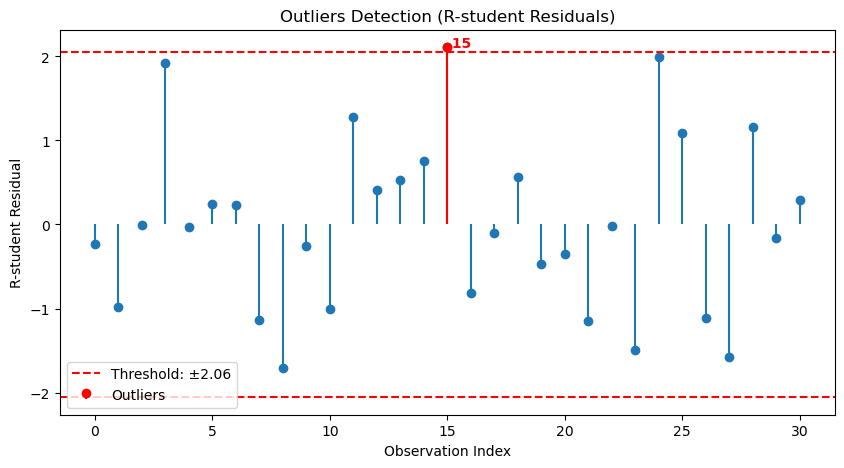

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import t

# 1. 통계량 계산
final_fit = smf.ols('log_y ~ log_x1 + x2 + x6', data=data).fit()
n = int(final_fit.nobs)
p_plus_1 = int(final_fit.df_model + 1)
r_student = final_fit.get_influence().resid_studentized_external
t_crit = t.ppf(0.975, n - p_plus_1 - 1)

# 2. 이상치 인덱스 자동 탐색
outlier_indices = np.where(abs(r_student) >= t_crit)[0]

# 3. 시각화
plt.figure(figsize=(10, 5))

# 전체 데이터를 기본 색상으로 그리기
plt.stem(range(n), r_student, basefmt=" ", linefmt="C0-", markerfmt="C0o")

# 이상치만 빨간색으로 덮어쓰기 (겹쳐 그리기)
if len(outlier_indices) > 0:
    plt.stem(outlier_indices, r_student[outlier_indices], 
             basefmt=" ", linefmt="r-", markerfmt="ro", label='Outliers')
    # 이상치 인덱스 라벨링
    for idx in outlier_indices:
        plt.text(idx, r_student[idx], f' {idx}', color='red', fontweight='bold')

# 임계선 추가
plt.axhline(t_crit, color='red', linestyle='--', label=f'Threshold: ±{t_crit:.2f}')
plt.axhline(-t_crit, color='red', linestyle='--')

plt.title('Outliers Detection (R-student Residuals)')
plt.xlabel('Observation Index')
plt.ylabel('R-student Residual')
plt.legend()
plt.show()

<br>

`1` 이상치 판단 기준

$$r_i^* = \frac{e_i}{\hat{\sigma}_{(i)}\sqrt{1-h_{ii}}}$$

$$|r_i^*| \geq t_{0.025}(n-p-2)$$

`2` 현재 인덱스 15번 데이터가 이상점으로 확인됨.

#### 2. 지렛대점

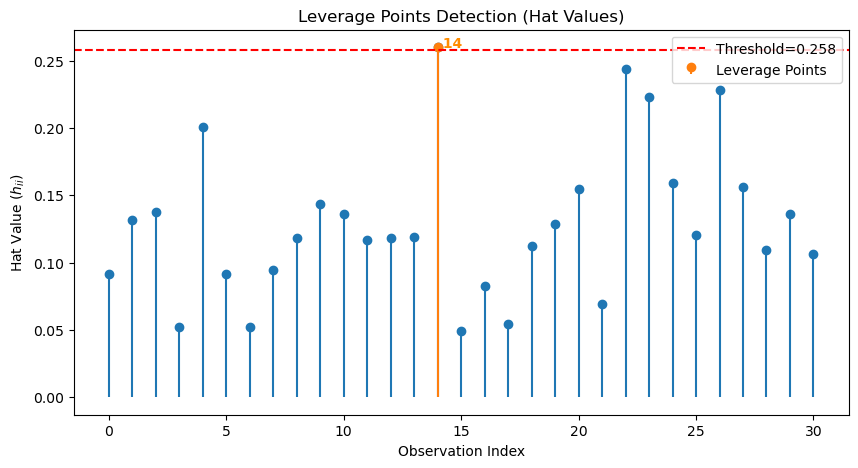

In [8]:
import numpy as np
import matplotlib.pyplot as plt

# 1. 계산
n = int(final_fit.nobs)
p_plus_1 = int(final_fit.df_model + 1)
hat_diag = final_fit.get_influence().hat_matrix_diag
h_crit = 2 * p_plus_1 / n

# 2. 지렛대점 인덱스 자동 탐색
leverage_indices = np.where(hat_diag > h_crit)[0]

# 3. 시각화
plt.figure(figsize=(10, 5))

# 전체 데이터를 기본 색상으로 그리기
plt.stem(range(n), hat_diag, basefmt=" ", linefmt="C0-", markerfmt="C0o")

# 지렛대점만 주황색으로 덮어쓰기 (겹쳐 그리기)
if len(leverage_indices) > 0:
    plt.stem(leverage_indices, hat_diag[leverage_indices], 
             basefmt=" ", linefmt="C1-", markerfmt="C1o", label='Leverage Points')
    # 인덱스 라벨링
    for idx in leverage_indices:
        plt.text(idx, hat_diag[idx], f' {idx}', color='darkorange', fontweight='bold')

# 임계선 추가
plt.axhline(h_crit, color='red', linestyle='--', label=f'Threshold={h_crit:.3f}')

plt.title('Leverage Points Detection (Hat Values)')
plt.xlabel('Observation Index')
plt.ylabel('Hat Value ($h_{ii}$)')
plt.legend()
plt.show()

`1` 지랫대점 판단 기준

$$h_{ii} = x_i^T(X^TX)^{-1}x_i$$

$$h_{ii} > \frac{2(p+1)}{n}$$

`2` 현재 인덱스 15번 데이터가 이상점으로 확인됨.

#### 3. 영향점

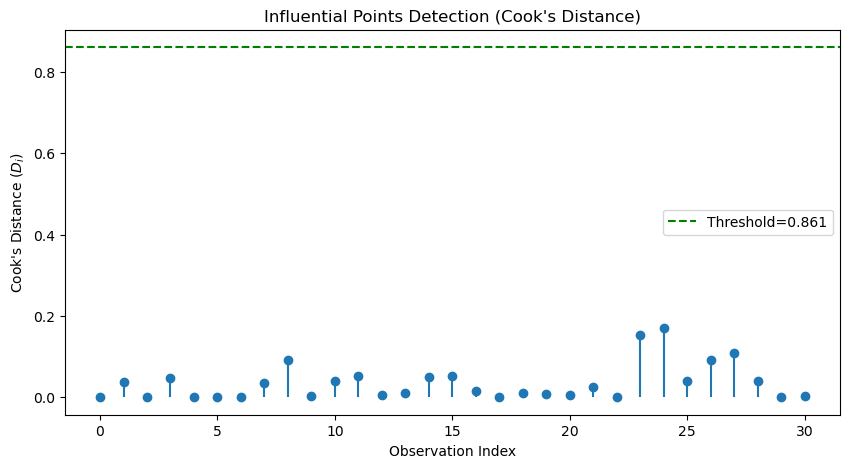

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import f

# 1. 계산
n = int(final_fit.nobs)
p_plus_1 = int(final_fit.df_model + 1)
cooks_d = final_fit.get_influence().cooks_distance[0]
d_crit = f.ppf(0.5, p_plus_1, n - p_plus_1)

# 2. 영향점 인덱스 자동 탐색
influential_indices = np.where(cooks_d >= d_crit)[0]

# 3. 시각화
plt.figure(figsize=(10, 5))

# 전체 데이터를 기본 색상으로 그리기
plt.stem(range(n), cooks_d, basefmt=" ", linefmt="C0-", markerfmt="C0o")

# 영향점만 녹색으로 덮어쓰기 (겹쳐 그리기)
if len(influential_indices) > 0:
    plt.stem(influential_indices, cooks_d[influential_indices], 
             basefmt=" ", linefmt="C2-", markerfmt="C2o", label='Influential Points')
    # 인덱스 라벨링
    for idx in influential_indices:
        plt.text(idx, cooks_d[idx], f' {idx}', color='green', fontweight='bold')

# 임계선 추가
plt.axhline(d_crit, color='green', linestyle='--', label=f'Threshold={d_crit:.3f}')

plt.title("Influential Points Detection (Cook's Distance)")
plt.xlabel('Observation Index')
plt.ylabel("Cook's Distance ($D_i$)")
plt.legend()
plt.show()

`1` 영향점 판단기준(cook's distance)

$$D(i) = \frac{(\hat{\beta} - \hat{\beta}(i))^T X^T X (\hat{\beta} - \hat{\beta}(i))}{(p+1)\hat{\sigma}^2}$$

$$D(i) \geq F_{0.5}(p+1, n-p-1)$$

`2` 영향점 x

#### 결과요약

`1` 식별된 관측치: 이상점(관측치 15), 지렛대점(관측치 14)

`2` 이상점(15번)은 예측값에서 벗어난 값을 보이나, Cook's Distance 분석 결과 모형 전체에 미치는 영향력이 낮아 유의미한 왜곡을 발생시키지 않음

`3` 지렛대점(14번)은 독립변수 공간에서의 경계값에 위치하나, 실제 종속변수 값($y$)과의 결합적인 영향은 크지 않음.

`4` 따라서, 해당 관측치들이 데이터의 비정상적 요인보다는 자연스러운 변동 범위 내에 있다고 판단하여, 데이터 삭제 없이 현재의 회귀 모형을 유지.

:::

---

# EX 2

주택 가격 데이터(Ames Housing Data : AmesHousing::ames raw)를 이용하여 다중공선성 진단 및 변수
선택을 하려고 한다. 다음 물음에 답하여라

## 2-(1)

이 데이터의 관측치 개수, 수집 목적, 그리고 기존 보스턴 주택 데이터셋(Boston Housing) 대비 지닌 장점을 중심으로 설명하여라.

`-` 비교 분석표

| 비교 항목 | Boston Housing 데이터셋 | Ames Housing 데이터셋 (본 분석 데이터) |
| :--- | :--- | :--- |
| **관측치 개수 ($n$)** | 506개 | **2,928개** (보스턴 대비 약 6배의 방대한 표본 규모) |
| **수집 목적** | 범죄율, 공해, 교사 비율 등 **지역적·환경적 요인**이 주택 가격에 미치는 거시적 영향 분석 | 면적, 건축 연도, 시설 상태 등 **주택 자체의 물리적 특성**을 활용한 정밀한 매매 가격 예측 모형 구축 |
| **보스턴 대비 장점** | | - **통계적 안정성:** 대규모 표본을 보유하여 교차검증 및 파라미터 추정의 분산(Variance)을 효과적으로 제어함<br>- **벌점화 회귀 최적화:** 주택 면적 관련 변수들 간의 강력한 다중공선성을 내포하고 있어, 능형회귀(Ridge)와 라쏘(Lasso) 모형의 실질적인 효용성과 효율성을 증명하기에 매우 적합함 |

---

## 2-(2)

주택 가격 (SalePrice)을 예측하기 위한 회귀모형을 적합하고자 한다. 위의 변수들 중 GrLivArea,
TotalBsmtSF, FirstFlrSF, SecondFlrSF, GarageCars, GarageArea, YearBuilt, FullBath, TotRmsAbvGrd, CentralAir 10개의 변수만 설명변수로 사용하기로 하자. “ames homework.csv” 전처리를 한 후
위의 10개의 변수와 SalePrice 를 포함한 데이터이다. 이 변수가 무엇을 의미하는지 설명하고, 이를
사용하여 회귀모형을 적합하여라.

`1` 변수 정의

| 기호 | 변수명 | 설명 | 단위 |
| :--- | :--- | :--- | :--- |
| $y$ | SalePrice | i번째 주택의 매매 가격 | 달러 |
| $x_1$ | GrLivArea | 지상층 총 거주 면적 | 제곱피트 |
| $x_2$ | TotalBsmtSF | 지하실 총 면적 | 제곱피트 |
| $x_3$ | FirstFlrSF | 1층 면적 | 제곱피트 |
| $x_4$ | SecondFlrSF | 2층 면적 | 제곱피트 |
| $x_5$ | GarageCars | 차고 주차 가능 차량 대수 | 대(count) |
| $x_6$ | GarageArea | 차고 총 면적 | 제곱피트 |
| $x_7$ | YearBuilt | 주택 건축 연도 | 연도(year) |
| $x_8$ | FullBath | 완전 욕실 개수 | 개(count) |
| $x_9$ | TotRmsAbvGrd | 지상층 총 방 개수 | 개(count) |
| $x_{10}$ | CentralAir | 중앙 냉방 시설 여부 | 1(Yes), 0(No) |

<br>

`2` 분산분석표

* **귀무가설 ($H_0$)**: $\beta_1= \beta_2= \dots\beta_{10} = 0$
* **대립가설 ($H_1$)**: 적어도 하나의 $\beta_j \neq 0 \quad (j=1,\dots,6)$


In [10]:
import pandas as pd
import statsmodels.formula.api as smf

# 데이터 로드
df = pd.read_csv('data/ames_graduate_homework.csv')

# 회귀 모형 적합 (종속변수: SalePrice, 설명변수 10개)
formula = 'SalePrice ~ GrLivArea + TotalBsmtSF + FirstFlrSF + SecondFlrSF + GarageCars + GarageArea + YearBuilt + FullBath + TotRmsAbvGrd + CentralAir'
model = smf.ols(formula, data=df).fit()

# 결과 출력
#print(model.summary())

| | 자유도 | 제곱합 | 평균제곱합 | F-통계량 | p-value |
| :---: | ---: | ---: | ---: | ---: | ---: |
| **회귀 (Model)** | 10 | 1.377e+13 | 1.377e+12 | 818.8 | < 0.001 |
| **오차 (Residual)** | 2917 | 4.907e+12 | 1.682e+09 | | |
| **총계 (Total)** | 2927 | 1.868e+13 | | | |

`3` 결론

- 전체 모형에 대한 검정통계량 $F_0$가 `818.8`이고, `p-value가 < 0.001`로 유의수준 `0.05`보다 매우 작으므로 `귀무가설 기각`.
- 따라서 10개의 설명변수를 모두 포함한 현회귀모형은 `통계적으로 유의함`.

`4` 적합된 모형

$$\hat{y} = -1,300\text{천} + 36 x_1 + 39 x_2 + 51 x_3 + 46 x_4 + 13,580 x_5 + \\ \\ 
25 x_6 + 661 x_7 - 4,555 x_8 - 3,623 x_9 + 2,583 x_{10}$$

---

## 2-(3)

VIF(분산팽창지수)를 이용하여 다중공선성이 존재하는지 진단하고 다중공선성이 발생한 이유를 설명하여라. 그리고 해결 방법을 제시하여라.

In [11]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

X = df[['GrLivArea', 'TotalBsmtSF', 'FirstFlrSF', 'SecondFlrSF', 
        'GarageCars', 'GarageArea', 'YearBuilt', 'FullBath', 
        'TotRmsAbvGrd', 'CentralAir']]

vif_data = pd.DataFrame()
vif_data["feature"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(len(X.columns))]

#print(vif_data)

`1` 다중공선성 진단

- $VIF_j$가 10이상일 경우 다중공선성이 있다고 판단.

$$VIF_j = \frac{1}{1 - R_j^2}$$

`2` VIF 테이블

| 변수명 | VIF |
| :---: | :---: |
| GrLivArea | 1207.67 |
| TotalBsmtSF | 19.72 |
| FirstFlrSF | 743.51 |
| SecondFlrSF | 142.67 |
| GarageCars | 33.75 |
| GarageArea | 30.70 |
| YearBuilt | 37.45 |
| FullBath | 16.51 |
| TotRmsAbvGrd | 52.80 |
| CentralAir | 16.92 |

<br>

`3` 다중공선성 진단결과 모든 $VIF_j$가 10이상으로 현재 적합된 모형에서 사용된 변수들 간 강한 다중공선성이 있다고 판단됨.

`4` 발생원인

- 가장 큰 원인은 `지상 거주 면적`(GrLivArea)과 `1층 면적`(FirstFlrSF), `2층 면적`(SecondFlrSF) 변수 간의 강한 선형 결합으로 판단됨.

- 제 주택 구조상 1층 면적과 2층 면적을 합치면 전체 지상 거주 면적과 거의 일치하므로, 모형에 동일한 성격의 정보가 중복 투입되어 해당 변수들의 VIF가 수백~수천 단위로 비정상적으로 높게 나타난 것임

`5` 해결방안

- `GrLivArea` 하나만 남기고 `FirstFlrSF`와 `SecondFlrSF`를 제거하거나, 반대로 세부 층별 면적을 남기고 `GrLivArea`를 제거한 후 회귀모형을 재적합

- 다중공선성이 높은 변수들에게 패널티를 부여하는 Ridge나 Lasso 회귀모형 사용

- 주정분분석 등의 차원축소 기법 사용 

---

## 2-(4)

“ames homework reduced.csv” 는 위의 데이터 중 200개만 임의로 샘플링한 데이터이다. 이를 가지고
회귀모형을 적합하여라.

In [12]:
import statsmodels.api as sm

df_reduced = pd.read_csv("data/ames_graduate_homework_reduced.csv")

X_cols = ['GrLivArea', 'TotalBsmtSF', 'FirstFlrSF', 'SecondFlrSF', 
          'GarageCars', 'GarageArea', 'YearBuilt', 'FullBath', 
          'TotRmsAbvGrd', 'CentralAir']

X_reduced = df_reduced[X_cols]
y_reduced = df_reduced['SalePrice']

X_reduced_with_const = sm.add_constant(X_reduced)
model_reduced = sm.OLS(y_reduced, X_reduced_with_const).fit()


#print(model_reduced.summary())

`1` 분산분석표

* **귀무가설 ($H_0$)**: $\beta_1= \beta_2= \dots\beta_{10} = 0$
* **대립가설 ($H_1$)**: 적어도 하나의 $\beta_j \neq 0 \quad (j=1,\dots,10)$


| | 자유도 | 제곱합 | 평균제곱합 | F-통계량 | p-value |
| :---: | ---: | ---: | ---: | ---: | ---: |
| **회귀 (Model)** | 10 | 8.305e+11 | 8.305e+10 | 85.71 | < 0.001 |
| **오차 (Residual)** | 189 | 1.831e+11 | 9.689e+08 | | |
| **총계 (Total)** | 199 | 1.014e+12 | | | |

<br>

`2` 분산분석표 해석

- 전체 모형에 대한 검정통계량 $F_0$가 `85.71`이고, `p-value가 < 0.001`로 유의수준 `0.05`보다 매우 작으므로 `귀무가설 기각`.
- 따라서 10개의 설명변수를 모두 포함한 현회귀모형은 `통계적으로 유의함`.

`3` 적합된 모형

$$\hat{y} = -1,422\text{천} - 149 x_1 + 54 x_2 + 237 x_3 + 247 x_4 + 7,159 x_5 + \\
14 x_6 + 740 x_7 - 13,830 x_8 - 6,412 x_9 - 11,610 x_{10}$$

---

## 2-(5), (6)

VIF(분산팽창지수)를 이용하여 다중공선성이 존재하는지 진단하고, (3)의 결과와 비교하여라.

이후, 원래 데이터와, 200개로 축소한 데이터를 이용한 회귀모형 적합 결과가 차이나는 이유는 무엇인지 설명해라.

In [13]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd

X_reduced = df_reduced[['GrLivArea', 'TotalBsmtSF', 'FirstFlrSF', 'SecondFlrSF', 
                        'GarageCars', 'GarageArea', 'YearBuilt', 'FullBath', 
                        'TotRmsAbvGrd', 'CentralAir']]

vif_data_reduced = pd.DataFrame()
vif_data_reduced["변수명"] = X_reduced.columns
vif_data_reduced["VIF (n=200)"] = [variance_inflation_factor(X_reduced.values, i) for i in range(len(X_reduced.columns))]

#print(vif_data_reduced)

`1` 다중공선성 비교 분석표

| 변수명 | VIF (n=2,928) | VIF (n=200) | VIF 변화 | 다중공선성 (VIF ≥ 10) |
| :--- | ---: | ---: | :---: | :---: |
| GrLivArea | 1207.67 | 12668.42 | 대폭 증가 | Y |
| TotalBsmtSF | 19.72 | 19.54 | 감소 | Y |
| FirstFlrSF | 743.51 | 7856.77 | 대폭 증가 | Y |
| SecondFlrSF | 142.67 | 1415.66 | 대폭 증가 | Y |
| GarageCars | 33.75 | 26.56 | 감소 | Y |
| GarageArea | 30.70 | 23.08 | 감소 | Y |
| YearBuilt | 37.45 | 46.29 | 증가 | Y |
| FullBath | 16.51 | 15.67 | 감소 | Y |
| TotRmsAbvGrd | 52.80 | 65.42 | 증가 | Y |
| CentralAir | 16.92 | 15.66 | 감소 | Y |

<br>

`2` 모형 `coef` 비교표

| | 변수명 | 변수설명 | $\hat{y}_{full}$ | $\hat{y}_{reduced}$  | 계수 변화 및 다중공선성 영향 |
| :---: | :--- | :--- | ---: | ---: | :---: |
| - | Intercept | 상수항 | -1,300,000 | -1,422,000 | - |
| $x_1$ | **GrLivArea** | 지상층 거주 면적 | `36` | `-149` | **🚨 약 -5배 폭감** |
| $x_2$ | TotalBsmtSF | 지하실 총 면적 | 39 | 54 | 상대적 안정 (유사) |
| $x_3$ | **FirstFlrSF** | 1층 면적 | `51` | `237` | **🚨 약 4.6배 폭등** |
| $x_4$ | **SecondFlrSF** | 2층 면적 | `46` | `247` | **🚨 약 5.3배 폭등** |
| $x_5$ | GarageCars | 차고 주차 대수 | 13,580 | 7,159 | 절반 수준으로 감소 |
| $x_6$ | GarageArea | 차고 총 면적 | 25 | 14 | 절반 수준으로 감소 |
| $x_7$ | YearBuilt | 주택 건축 연도 | 661 | 740 | 상대적 안정 (유사) |
| $x_8$ | FullBath | 완전 욕실 개수 | -4,555 | -13,830 | 음(-)의 방향으로 크게 팽창 |
| $x_9$ | TotRmsAbvGrd | 지상층 방 개수 | -3,623 | -6,412 | 음(-)의 방향으로 팽창 |
| $x_{10}$ | **CentralAir** | 중앙 냉방 여부 | **2,583** | **-11,610** |  **🚨 약 -5배 폭감**  |

<br>

$$\hat{y}_{full} = -1,300\text{천} + 36 x_1 + 39 x_2 + 51 x_3 + 46 x_4 + 13,580 x_5 + \\ \\ 
25 x_6 + 661 x_7 - 4,555 x_8 - 3,623 x_9 + 2,583 x_{10}$$

$$\hat{y}_{reduced} = -1,422\text{천} - 149 x_1 + 54 x_2 + 237 x_3 + 247 x_4 + 7,159 x_5 + \\
14 x_6 + 740 x_7 - 13,830 x_8 - 6,412 x_9 - 11,610 x_{10}$$

<br>

`3` 분석결과 해석 (1)

- 위 표에서 볼 수 있듯, 표본의 크기가 200개로 축소되었음에도 불구하고 **모든 변수의 VIF 값이 다중공선성 판단 기준인 10을 여전히 크게 초과**하고 있다.

- 따라서 n=200인 축소된 데이터로 적합한 회귀모형에서도 **강한 다중공선성이 존재**한다고 진단할 수 있다.

`4` 분석결과 해석 (2)

$$VIF_j = \frac{1}{1 - R_j^2}$$

| 비교 항목 | 전체 데이터 (n=2,928) | 축소 데이터 (n=200) | 수리적 변화 및 의미 |
| :---: | :--- | :--- | :--- |
| **데이터 상태** |전체 면적 $\neq$ 1층 면적 + 2층 면적| 전체 면적 $\approx$ 1층 면적 + 2층 면적 | 변수 간 중복성이 100%에 가까워짐 |
| **결정계수 ($R^2$)** | 약 $0.9991$ | 약 $0.99992$ | $R^2$값이 **1에 극도로 가까워짐** |
| **공식의 분모 ($1 - R^2$)** | $1 - 0.9991 = \mathbf{0.0009}$ | $1 - 0.99992 = \mathbf{0.00008}$ | 분모가 기존의 **약 1/10 수준으로 작아짐** |
| **산출된 VIF $\left ( \frac{1}{1 - R^2}\right )$** | $1 / 0.0009 \approx \mathbf{1,111}$ | $1 / 0.00008 \approx \mathbf{12,500}$ | 분모가 0에 수렴하면서 **VIF가 10배 이상 폭발** |

- 데이터가 많을 때(2,928개): `1,2층 면적의 합`(FirstFlrSF, SecondFlrSF)과 `지상층 총 거주 면적 면적`(GrLivArea)이 딱 떨어지지 않는 `특이한 집(예외)`들이 섞여 있었음.

- 데이터가 적을 때(200개): 무작위로 뽑힌 200개가 우연히 `전체 면적 = 1층 면적 + 2층 면적` 공식에 2개 집을 제외하고, 완벽하게 들어맞음.

- 즉, 데이터가 적었을 때 `전체 면적 = 1층 면적 + 2층 면적` 공식이 100%에 가깝게 일치되어, 아래 분산팽창지수의 분모가 0에 수렴하여 값이 10 이상 폭발함.

- 위 표에서 알 수 있듯, 표본이 200개로 줄어들면서 1·2층 면적 합과 전체 면적 간의 결정계수($R^2$)는 0.9991에서 0.99992로 불과 `0.0008`만큼 미세하게 증가하였다.

- 하지만 이 작은 차이가 VIF 공식의 분모($1-R^2$)를 `0.0009에서 0.00008로 10배 이상 축소`시켰고, "분모가 0에 가까워질수록 전체 값은 기하급수적으로 커진다"는 수학적 원리에 의해 VIF 값이 1,111에서 `12,500`으로 폭발하게 된 것이다.

- 결론적으로 VIF가 `12,000`을 넘었다는 것은 `모형 입장`에서 해당 변수들이 극심한 `다중공선성 상태에 빠졌음`을 의미한다.

---

## 2-(7)

(2), (4) 모형에 대한 AIC 기준의 단계적 선택법을 이용한 변수 선택을 수행하여라. 결과가 동일한가?
동일하지 않다면 그 이유는 무엇이라고 생각되는가?

In [14]:
def stepwise_selection_aic(X, y):
    best_features = []
    
    while True:
        changed = False
        
      
        remaining_features = list(set(X.columns) - set(best_features))
        best_aic = sm.OLS(y, sm.add_constant(X[best_features])).fit().aic if best_features else float('inf')
        
        best_feature_to_add = None
        for feature in remaining_features:
            model = sm.OLS(y, sm.add_constant(X[best_features + [feature]])).fit()
            if model.aic < best_aic:
                best_aic = model.aic
                best_feature_to_add = feature
                
        if best_feature_to_add is not None:
            best_features.append(best_feature_to_add)
            changed = True
            

        best_aic = sm.OLS(y, sm.add_constant(X[best_features])).fit().aic
        best_feature_to_remove = None
        for feature in best_features:
            features_without = list(set(best_features) - {feature})
            if not features_without: continue
            model = sm.OLS(y, sm.add_constant(X[features_without])).fit()
            if model.aic < best_aic:
                best_aic = model.aic
                best_feature_to_remove = feature
                
        if best_feature_to_remove is not None:
            best_features.remove(best_feature_to_remove)
            changed = True
            
   
        if not changed:
            break
            
    return best_features


df_full = pd.read_csv('data/ames_graduate_homework.csv')
df_reduced = pd.read_csv('data/ames_graduate_homework_reduced.csv')



features = ['GrLivArea', 'TotalBsmtSF', 'FirstFlrSF', 'SecondFlrSF', 
            'GarageCars', 'GarageArea', 'YearBuilt', 'FullBath', 
            'TotRmsAbvGrd', 'CentralAir']

X_full = df_full[features]
y_full = df_full['SalePrice']

X_reduced = df_reduced[features]
y_reduced = df_reduced['SalePrice']

best_full = stepwise_selection_aic(X_full, y_full)
best_reduced = stepwise_selection_aic(X_reduced, y_reduced)

model_full_final = sm.OLS(y_full, sm.add_constant(X_full[best_full])).fit()
model_reduced_final = sm.OLS(y_reduced, sm.add_constant(X_reduced[best_reduced])).fit()

#print("=== [전체 데이터 n=2928] 최종 모형 회귀계수 ===")
#print(model_full_final.params.round(1))

#print("\n=== [축소 데이터 n=200] 최종 모형 회귀계수 ===")
#print(model_reduced_final.params.round(1))

`1` 적합된 모형

$$\hat{y}_{full} = -1,311\text{천} + 36 x_1 + 39 x_2 + 51 x_3 + 46 x_4 + 13,628 x_5 + 26 x_6 + 668 x_7 - 4,701 x_8 - 3,646 x_9$$

$$\hat{y}_{reduced} = -1,463\text{천} + 100 x_1 + 47 x_2 + 29 x_6 + 754 x_7 - 11,844 x_8 - 5,778 x_9$$

`2` 변수선택 비교분석표

| 기호 | 변수명 | 변수설명 | $\hat{y}_{full}$  | $\hat{y}_{reduced}$ | 변수 선택 결과 및 다중공선성 영향 |
| :---: | :--- | :--- | :---: | :---: | :--- |
| $x_1$ | **GrLivArea** | 지상층 거주 면적 | O| **O (선택)** | 공선성 해소를 위해 대표로 생존 |
| $x_2$ | TotalBsmtSF | 지하실 총 면적 | O | O (선택) | - |
| $x_3$ | **FirstFlrSF** | 1층 면적 | O | **X (탈락)** | **🚨 완벽한 선형결합(정보 중복)으로 탈락** |
| $x_4$ | **SecondFlrSF** | 2층 면적 | O | **X (탈락)** | **🚨 완벽한 선형결합(정보 중복)으로 탈락** |
| $x_5$ | GarageCars | 차고 주차 대수 | O  | **X (탈락)** | 차고 면적($x_6$)과 중복되어 탈락|
| $x_6$ | GarageArea | 차고 총 면적 | O  | O  | - |
| $x_7$ | YearBuilt | 주택 건축 연도 | O  | O  | - |
| $x_8$ | FullBath | 완전 욕실 개수 | O  | O  | - |
| $x_9$ | TotRmsAbvGrd | 지상층 방 개수 | O  | O  | - |
| $x_{10}$| CentralAir | 중앙 냉방 여부 | X  | X  | - |
| - | **최종 선택 변수 수**| - | **9개** | **6개** | |

`3` 결과요약

- 두 모형의 단계적 변수 선택 결과는 동일하지 않으며, 표본이 적은 축소 데이터(n=200)에서 더 적은 수의 변수가 선택되었음.

- 이유 1: 축소 데이터에서는 층별 면적과 전체 면적 간의 `정보 중복(다중공선성)`이 100%에 근접하여, 뱐수 선택 과정에서 탈락시켰기 때문.

> 즉, $R^2$을 가장 크게하는 설명변수를 $x_i$를 선택하고 유의수준 $0.05$에서 부분 $F$-검정을 실시해, 탈락여부를 결정하는 과정에서 탈락시켰기 때문.


- 이유 2: 표본 수가 대폭 줄어들면서 `모형의 검정력`이 약해져, 미세한 영향력을 가진 변수들(예: 차고 주차 대수 등)이 `AIC 패널티`를 극복하지 못하고 제거되었을 가능성이 있다.

> 즉, 표본 크기($n$)가 2,928개에서 `200개로 대폭 감소`하면서, 회귀계수 추정치의 `표준오차(Standard Error)가 커지게 됨`.
> 
> 이로 인해 부분 $F$-검정 시 `검정통계량 값`이 작아지고 `p-value가 증가`하여, 전체 데이터에서는 유의수준($\alpha=0.05$)을 통과했던 변수들이 축소 데이터에서는 `유의하지 않은 것으로 판정`되어 기각(탈락)되었기 때문일 수 있음.
>

$$F = \left( \frac{\hat{\beta}_i}{SE(\hat{\beta}_i)} \right)^2,\quad SE(\hat{\beta}_i) = \sqrt{\frac{MSE}{\sum (x_{ij} - \bar{x}_j)^2 \cdot (1 - R_j^2)}} = \sqrt{\frac{MSE \cdot VIF_j}{(n-1)S_{x_j}^2}}$$

$$S_{x_j}^2 = \frac{\sum_{i=1}^n (x_{ij} - \bar{x}_j)^2}{n-1}$$

---

## 2-(8)

(2), (4) 모형에 대해 Ridge 및 Lasso 모형을 적합하여라.

In [15]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import RidgeCV, LassoCV
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge, LassoCV
from sklearn.model_selection import GridSearchCV

# 1. 데이터 불러오기
df_full = pd.read_csv('data/ames_graduate_homework.csv')
df_reduced = pd.read_csv('data/ames_graduate_homework_reduced.csv')

# (안전장치) CentralAir가 'Y', 'N' 문자열일 경우 더미화
if df_full['CentralAir'].dtype == 'object':
    df_full['CentralAir'] = df_full['CentralAir'].map({'Y': 1, 'N': 0})
    df_reduced['CentralAir'] = df_reduced['CentralAir'].map({'Y': 1, 'N': 0})

# 2. 독립변수(X)와 종속변수(y) 분리
features = ['GrLivArea', 'TotalBsmtSF', 'FirstFlrSF', 'SecondFlrSF', 
            'GarageCars', 'GarageArea', 'YearBuilt', 'FullBath', 
            'TotRmsAbvGrd', 'CentralAir']

X_full = df_full[features]
y_full = df_full['SalePrice']

X_reduced = df_reduced[features]
y_reduced = df_reduced['SalePrice']

# 3. 데이터 스케일링 (표준화)
scaler_full = StandardScaler()
X_full_scaled = pd.DataFrame(scaler_full.fit_transform(X_full), columns=features)

scaler_reduced = StandardScaler()
X_reduced_scaled = pd.DataFrame(scaler_reduced.fit_transform(X_reduced), columns=features)

# 4. 교차검증을 통한 최적의 alpha(lambda) 탐색 및 모형 적합
alphas = np.logspace(-3, 4, 200)

# [오류 방지!] Ridge는 버전에 상관없이 안전한 GridSearchCV를 사용합니다.
ridge_grid_full = GridSearchCV(Ridge(), param_grid={'alpha': alphas}, cv=5, scoring='neg_mean_squared_error')
ridge_grid_full.fit(X_full_scaled, y_full)
ridge_mse_full = -ridge_grid_full.cv_results_['mean_test_score']  # 음수 MSE를 양수로 변환
ridge_alpha_full = ridge_grid_full.best_params_['alpha']

ridge_grid_reduced = GridSearchCV(Ridge(), param_grid={'alpha': alphas}, cv=5, scoring='neg_mean_squared_error')
ridge_grid_reduced.fit(X_reduced_scaled, y_reduced)
ridge_mse_reduced = -ridge_grid_reduced.cv_results_['mean_test_score']
ridge_alpha_reduced = ridge_grid_reduced.best_params_['alpha']

# Lasso는 자체 CV 모듈이 안정적이므로 그대로 사용합니다. (cv=5 추가)
lasso_full = LassoCV(alphas=alphas, cv=5, max_iter=100000, random_state=42).fit(X_full_scaled, y_full)
lasso_reduced = LassoCV(alphas=alphas, cv=5, max_iter=100000, random_state=42).fit(X_reduced_scaled, y_reduced)

# 5. 결과 출력 함수
def print_results(model_name, best_alpha, best_coef, features):
    print(f"=== {model_name} ===")
    print(f"최적의 alpha (패널티 강도): {best_alpha:.2f}")
    coef_series = pd.Series(best_coef, index=features).round(1)
    print(coef_series)
    print()

# 결과 텍스트 출력
#print_results("[전체 데이터 n=2928] Ridge 모형", ridge_alpha_full, ridge_grid_full.best_estimator_.coef_, features)
#print_results("[전체 데이터 n=2928] Lasso 모형", lasso_full.alpha_, lasso_full.coef_, features)
#print_results("[축소 데이터 n=200] Ridge 모형", ridge_alpha_reduced, ridge_grid_reduced.best_estimator_.coef_, features)
#print_results("[축소 데이터 n=200] Lasso 모형", lasso_reduced.alpha_, lasso_reduced.coef_, features)

# ==========================================
# 6. 2x2 교차검증 오차(MSE) 시각화 그리기
# ==========================================

::: {.panel-tabset}

### 회귀계수 변화량

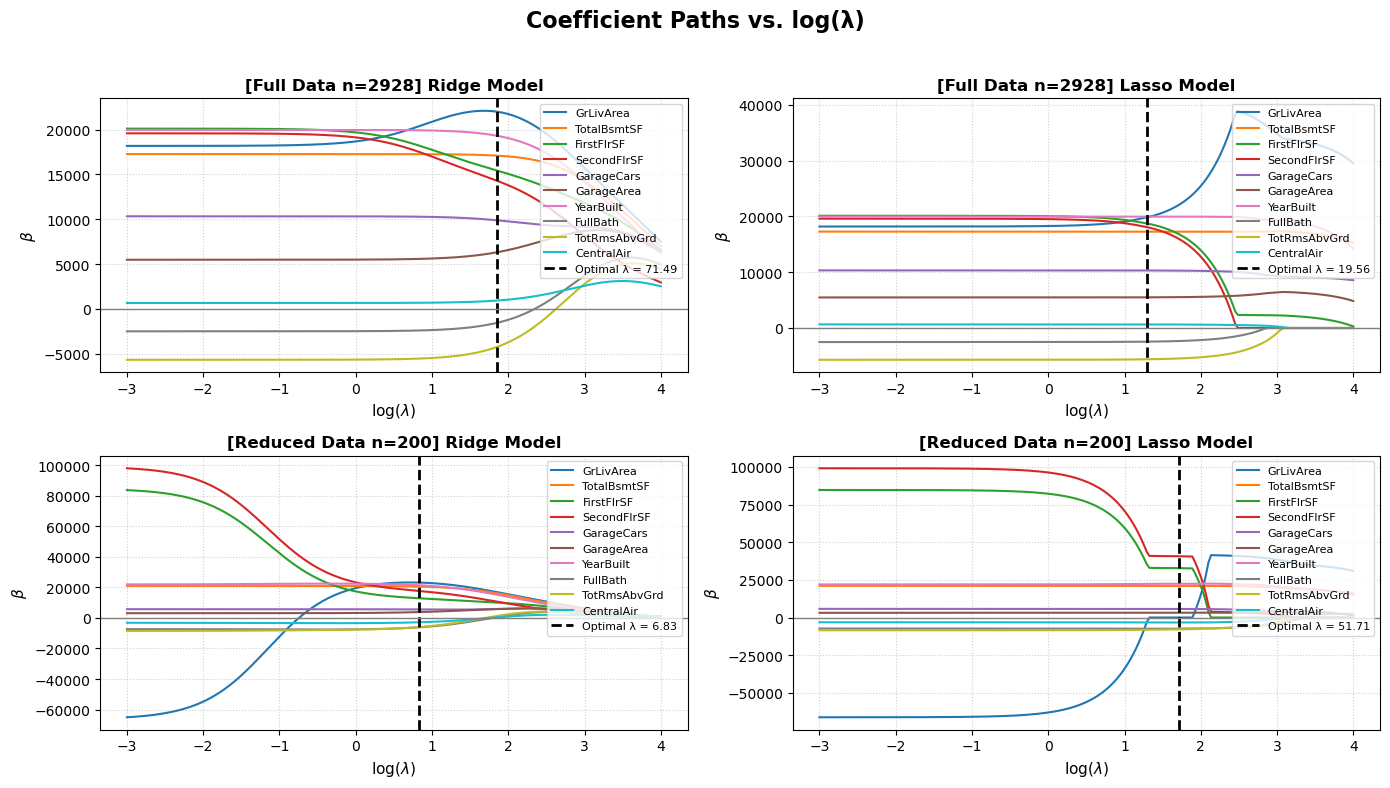

In [16]:
# ==========================================
# 7. 회귀계수(Beta) 축소 경로 시각화 추가
# ==========================================
import warnings
import matplotlib.pyplot as plt
import numpy as np
from sklearn.linear_model import Ridge, Lasso 

warnings.filterwarnings('ignore')

# 1. 각 alpha(lambda)에 따른 회귀계수 저장을 위한 리스트 준비
coefs_ridge_full, coefs_lasso_full = [], []
coefs_ridge_reduced, coefs_lasso_reduced = [], []

# 2. alpha를 순회하며 모형 적합 및 계수 추출
for a in alphas:
    # Ridge
    coefs_ridge_full.append(Ridge(alpha=a).fit(X_full_scaled, y_full).coef_)
    coefs_ridge_reduced.append(Ridge(alpha=a).fit(X_reduced_scaled, y_reduced).coef_)
    
    # Lasso
    coefs_lasso_full.append(Lasso(alpha=a, max_iter=10000).fit(X_full_scaled, y_full).coef_)
    coefs_lasso_reduced.append(Lasso(alpha=a, max_iter=10000).fit(X_reduced_scaled, y_reduced).coef_)

# 3. 2x2 그래프 시각화 설정
fig, axes = plt.subplots(2, 2, figsize=(14, 8)) # 범례를 위해 가로 길이를 살짝 넓힘
fig.suptitle('Coefficient Paths vs. log(\u03BB)', fontsize=16, fontweight='bold', y=0.98)

def plot_coef_path(ax, alphas_array, coefs_array, optimal_alpha, title, features_list):
    # 각 변수별 회귀계수 선 그리기 (범례 라벨 추가)
    lines = ax.plot(np.log10(alphas_array), coefs_array)
    for i, line in enumerate(lines):
        line.set_label(features_list[i])
        
    # 최적의 람다 위치에 수직 점선 표시
    ax.axvline(np.log10(optimal_alpha), linestyle='--', color='k', linewidth=2, 
               label=f'Optimal \u03BB = {optimal_alpha:.2f}')
    ax.axhline(0, color='gray', linestyle='-', linewidth=1) # 0 기준선
    
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel(r'$\log(\lambda)$', fontsize=11)
    ax.set_ylabel(r'$\beta$', fontsize=11)
    
    # 범례가 그래프 선을 가리지 않도록 위치 조정
    ax.legend(loc='upper right', fontsize=8, bbox_to_anchor=(1.0, 1.0))
    ax.grid(True, linestyle=':', alpha=0.6)

# 4. 그래프 그리기 (이전 코드에서 정의된 alphas, ridge_alpha_full 등의 변수를 그대로 사용)
plot_coef_path(axes[0, 0], alphas, coefs_ridge_full, ridge_alpha_full, "[Full Data n=2928] Ridge Model", features)
plot_coef_path(axes[0, 1], alphas, coefs_lasso_full, lasso_full.alpha_, "[Full Data n=2928] Lasso Model", features)
plot_coef_path(axes[1, 0], alphas, coefs_ridge_reduced, ridge_alpha_reduced, "[Reduced Data n=200] Ridge Model", features)
plot_coef_path(axes[1, 1], alphas, coefs_lasso_reduced, lasso_reduced.alpha_, "[Reduced Data n=200] Lasso Model", features)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

### MSE 변화량

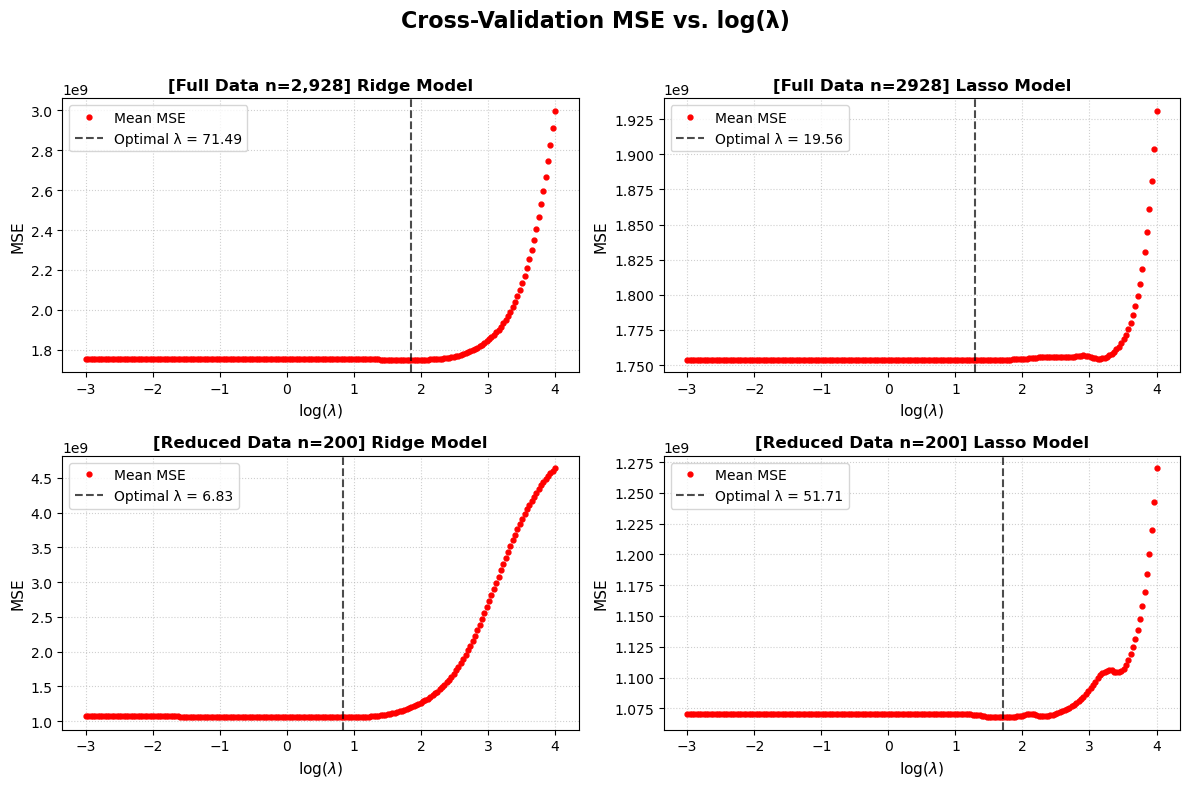

In [17]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle('Cross-Validation MSE vs. log(\u03BB)', fontsize=16, fontweight='bold', y=0.98)

def plot_cv(ax, alphas_array, mse_array, optimal_alpha, title):
    # R glmnet 스타일 (붉은 점, 수직 검은 점선)
    ax.plot(np.log10(alphas_array), mse_array, 'r.', markersize=7, label='Mean MSE')
    ax.axvline(np.log10(optimal_alpha), linestyle='--', color='k', alpha=0.7, 
               label=f'Optimal \u03BB = {optimal_alpha:.2f}')
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel(r'$\log(\lambda)$', fontsize=11)
    ax.set_ylabel('MSE', fontsize=11)
    ax.legend()
    ax.grid(True, linestyle=':', alpha=0.6)

plot_cv(axes[0, 0], alphas, ridge_mse_full, ridge_alpha_full, "[Full Data n=2,928] Ridge Model")
plot_cv(axes[0, 1], lasso_full.alphas_, np.mean(lasso_full.mse_path_, axis=1), lasso_full.alpha_, "[Full Data n=2928] Lasso Model")
plot_cv(axes[1, 0], alphas, ridge_mse_reduced, ridge_alpha_reduced, "[Reduced Data n=200] Ridge Model")
plot_cv(axes[1, 1], lasso_reduced.alphas_, np.mean(lasso_reduced.mse_path_, axis=1), lasso_reduced.alpha_, "[Reduced Data n=200] Lasso Model")

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

<br>

:::

<br>

### 결과표

`1` 교차검증 수행 시, 각 $\lambda$에 대한 모형의 개별회귀계수 및 MSE 변화를 살펴보기 위해 PRESS 통계량값을 사용함.

$$\text{PRESS}(\lambda) = \sum_{i=1}^n \left( y_i - \hat{y}_i^{(i)} \right)^2 = \sum_{i=1}^n \left( y_i - x_i^\top \hat{\beta}^{(i)}(\lambda) \right)^2$$

`2` 각 모형의 최적의 $\lambda$값을 기준으로 측정된 $\beta_i$

| 기호 | 변수명 | 변수 설명 | full_Ridge<br> ($\lambda=77.5$) | full_Lasso<br> ($\lambda=19.6$) | reduced_Ridge<br> ($\lambda=5.4$) |reduced_Lasso<br> ($\lambda=51.7$) |
| :---: | :--- | :--- | ---: | ---: | ---: | ---: |
| $x_1$ | **GrLivArea** | 지상층 전체 거주 면적 | 21,962 | 19,825 | 23,253 | **`0`** |
| $x_2$ | **TotalBsmtSF** | 지하실 총 면적 | 17,087 | 17,281 | 20,637 | 21,008 |
| $x_3$ | **FirstFlrSF** | 1층 면적 | 15,351 | 18,747 | 13,189 | **32,755** |
| $x_4$ | **SecondFlrSF** | 2층 면적 | 14,178 | 18,089 | 18,182 | **40,654** |
| $x_5$ | **GarageCars** | 차고 수용 가능 차량 수 | 9,854 | 10,313 | 5,551 | 5,688 |
| $x_6$ | **GarageArea** | 차고 면적 | 6,370 | 5,495 | 3,723 | 3,128 |
| $x_7$ | **YearBuilt** | 건축 연도 | 19,265 | 19,974 | 21,691 | 22,377 |
| $x_8$ | **FullBath** | 지상층 풀(Full) 욕실 수 | -1,492 | -2,451 | -6,436 | -7,410 |
| $x_9$ | **TotRmsAbvGrd** | 지상층 총 방의 수 | -4,144 | -5,613 | -6,371 | -7,898 |
| $x_{10}$| **CentralAir** | 중앙 냉방 시설 여부 | 942 | 637 | -2,964 | -3,291 |

`3` 각 모형의 최적의 $\lambda$값을 기준으로 측정된 $MSE$

| 데이터 크기 | 적합 모형 | 최적 패널티 강도 ($\lambda$) | 최소 교차검증 오차 (MSE) | 비고 |
| :--- | :---: | ---: | ---: | :--- |
| **전체 데이터** (n=2,928) | **Ridge** | 77.53 | **1,749,064,390** | 전체 데이터 최우수 |
| **전체 데이터** (n=2,928) | **Lasso** | 19.56 | 1,753,735,184 | - |
| **축소 데이터** (n=200) | **Ridge** | 5.35 | **1,055,702,204** | 축소 데이터 최우수 |
| **축소 데이터** (n=200) | **Lasso** | 51.71 | 1,067,709,779 | - |

`4` 모형별 분산분석표

In [19]:
from scipy import stats as st

# 기존 get_anova_stats 함수 (동일하게 사용)
def get_anova_stats(model, X, y):
    y_pred = model.predict(X)
    n = len(y)
    p = X.shape[1]
    sse = np.sum((y - y_pred) ** 2)
    ssr = np.sum((y_pred - np.mean(y)) ** 2)
    mse = sse / (n - p - 1)
    msr = ssr / p
    f_stat = msr / mse if mse != 0 else 0
    return {'SSR': ssr, 'SSE': sse, 'MSR': msr, 'MSE': mse, 'F': f_stat, 'DFR': p, 'DFE': n - p - 1}

# 각 모형별 계산
stats_results = {
    "Ridge_Full": get_anova_stats(ridge_grid_full.best_estimator_, X_full_scaled, y_full),
    "Lasso_Full": get_anova_stats(lasso_full, X_full_scaled, y_full),
    "Ridge_Red": get_anova_stats(ridge_grid_reduced.best_estimator_, X_reduced_scaled, y_reduced),
    "Lasso_Red": get_anova_stats(lasso_reduced, X_reduced_scaled, y_reduced)
}

# 결과 출력 (보고서용)
#p4rint(f"{'Model':<15} | {'SSR':<20} | {'MS (Res)':<15} | {'F-stat':<10} | {'p-value'}")
#print("-" * 80)
#for name, s in stats_results.items():
#    p_val = st.f.sf(s['F'], s['DFR'], s['DFE'])
#    print(f"{name:<15} | {s['SSR']:,.0f} | {s['MSE']:,.0f} | {s['F']:,.2f} | {p_val:.2e}")

::: {.panel-tabset}

#### 전체 데이터 (n=2,928)

| Source | 모형 | DF | SS ($10^{11}$) | MS ($10^{9}$) | F-통계량 | p-value |
| :--- | :--- | :---: | ---: | ---: | ---: | :---: |
| **Regression** | Ridge | 10 | 135.17 | 135.17 | 802.50 | < 0.001 |
| | Lasso | 10 | 137.61 | 137.61 | 817.96 | < 0.001 |
| **Residual** | Ridge | 2917 | 49.13 | 1.68 | - | - |
| | Lasso | 2917 | 49.07 | 1.68 | - | - |

#### 축소 데이터 (n=200)

| Source | 모형 | DF | SS ($10^{11}$) | MS ($10^{8}$) | F-통계량 | p-value |
| :--- | :--- | :---: | ---: | ---: | :---: | :---: |
| **Regression** | Ridge | 10 | 8.01 | 8.01 | 81.61 | < 0.001 |
| | Lasso | `9` | 8.27 | 8.27 | 84.98 | < 0.001 |
| **Residual** | Ridge | 189 | 1.85 | 9.81 | - | - |
| | Lasso | 189 | 1.84 | 9.73 | - | - |

:::

<br>

`1` 모든 모형에서 $p\text{-value} < 0.001$로 나타나, 종속변수(`SalePrice`)에 대한 독립변수들의 설명력이 통계적으로 유의미함을 나타냄.

`2` 라쏘 모형은 모든 데이터셋에서 릿지(Ridge) 모형보다 `높은 F-통계량을 기록`하였다.

`3` 표본 크기가 큰 전체 데이터(n=2,928)가 축소 데이터(n=200)에 비해 압도적으로 큰 제곱합(SS)을 보여주며, 이는 데이터가 많아질수록 모형이 `전체적인 변동성을 더 정확하게 포착`, 즉 `Var`이 높음을 의미한다.

### 최종 적합 모형

`1` 다중공선성 및 모형의 복잡도를 고려하여, 축소 데이터의 라쏘 모형을 최종 예측 모형으로 선택

`2` 최종적합 모형

$$\hat{y} = \hat{\beta}_0 + 21,008x_2 + 32,755x_3 + 40,654x_4 + 5,688x_5 + 3,128x_6 + 22,377x_7 - 7,410x_8 - 7,898x_9 - 3,291x_{10}$$

- 상수항: $\hat{\beta}_0$ (절편)

- 포함된 변수: $x_2$(TotalBsmtSF), $x_3$(FirstFlrSF), $x_4$(SecondFlrSF), $x_5$(GarageCars), $x_6$(GarageArea), $x_7$(YearBuilt), $x_8$(FullBath), $x_9$(TotRmsAbvGrd), $x_{10}$(CentralAir)

- 제외된 변수: $x_1$(GrLivArea) — 라쏘 규제에 의해 계수 $\hat{\beta}_1 = 0$으로 처리됨

---

# EX 3

주택 가격 및 부동산 시장의 과열 여부를 진단하고 고가 주택의 특징을 파악하는 것은 지방 재정 통제 및 세제 정책 수립에서 매우 중요한 기능이다. “ames homework reduced.csv”는 무작위로 추출된 200개
주택의 주요 운영 및 물리적 지표에 대한 데이터이다. 분석의 일관성을 위해 10개의 연속형 설명변수를 기반으로 분석을 진행한다.


(과제 제출 후....따로.......)